<a href="https://colab.research.google.com/github/divyayalam/Camouflage/blob/rishikesh-track2/track2_prediction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/divyayalam/Camouflage.git
%cd Camouflage

Cloning into 'Camouflage'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), done.
/content/Camouflage


In [3]:
!ls
!cat README.md
!git branch -a

README.md
# Camouflage

CAMouflage is a research style tool for detecting and diagnosing "shortcut learning" in image classifiers - cases where a model achieves high accuracy by relying on spurious cues (background color, a watermark, a colored patch) instead of the actual object it's supposed to recognize.

Train a small CNN on a dataset with a deliberately injected shortcut, then use Grad-CAM and feature/channel ablation to visualize and quantify how much the model depends on that shortcut vs. the real signal. Everything is explorable live through an interactive dashboard: pick an image, see where the model is looking, ablate suspect features, and watch the prediction change in real time.

## Overview

Image classifiers can learn to exploit spurious correlations in training data rather than the features we actually care about. 
A model trained on images where, say, cats are usually photographed on red backgrounds may learn "red → cat" instead of "cat → cat."

CAMouflage makes this fa

In [4]:
!git clone https://github.com/divyayalam/Camouflage.git
%cd Camouflage
!ls
!git branch -a
!cat README.md
!git checkout -b rishikesh-track2
!git branch

Cloning into 'Camouflage'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), done.
/content/Camouflage/Camouflage
README.md
* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/main
# Camouflage

CAMouflage is a research style tool for detecting and diagnosing "shortcut learning" in image classifiers - cases where a model achieves high accuracy by relying on spurious cues (background color, a watermark, a colored patch) instead of the actual object it's supposed to recognize.

Train a small CNN on a dataset with a deliberately injected shortcut, then use Grad-CAM and feature/channel ablation to visualize and quantify how much the model depends on that shortcut vs. the real signal. Everything is explorable live through an interactive dashboard: pick an image, see where the model is looking, ablate su

In [5]:
!git checkout -b rishikesh-track2
!git branch


fatal: a branch named 'rishikesh-track2' already exists
  main
* rishikesh-track2


In [6]:
!mkdir -p notebooks
!mkdir -p models
!mkdir -p docs
!ls

docs  models  notebooks  README.md


In [7]:
!pip install torch torchvision torchaudio
!pip install grad-cam
!pip install numpy matplotlib pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=c86d92d25da5dc643c8fc11845ce3224bcdaf26a23865264d57f397ea41738a9
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


In [8]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.11.0+cu130
CUDA available: True


In [9]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor()
])

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = (
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

print("CIFAR-10 test set loaded:", len(testset), "images")

100%|██████████| 170M/170M [28:16<00:00, 100kB/s]


CIFAR-10 test set loaded: 10000 images


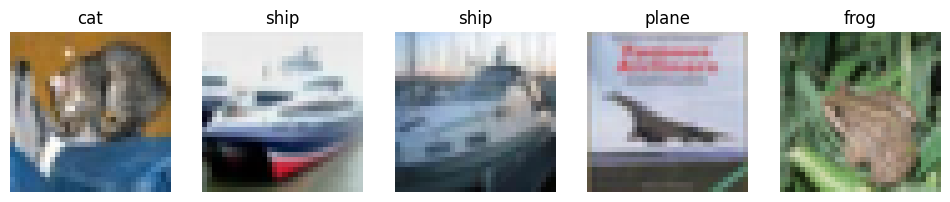

In [10]:
images, labels = next(iter(testloader))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image = images[i].permute(1, 2, 0)
    axes[i].imshow(image)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis("off")

plt.show()

In [12]:
!git pull origin main

From https://github.com/divyayalam/Camouflage
 * branch            main       -> FETCH_HEAD
Already up to date.


In [13]:
!find . -maxdepth 3 -type f | grep -v ".git"

./data/cifar-10-python.tar.gz
./data/cifar-10-batches-py/batches.meta
./data/cifar-10-batches-py/test_batch
./data/cifar-10-batches-py/data_batch_4
./data/cifar-10-batches-py/data_batch_1
./data/cifar-10-batches-py/data_batch_5
./data/cifar-10-batches-py/data_batch_3
./data/cifar-10-batches-py/readme.html
./data/cifar-10-batches-py/data_batch_2
./README.md


In [14]:
!git status


On branch rishikesh-track2
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/

nothing added to commit but untracked files present (use "git add" to track)


In [15]:
!git add .

In [16]:
!git commit -m "Set up Track 2 environment and CIFAR-10 analysis"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@1584298bb449.(none)')


In [18]:
!git config --global user.name "Rishi2914"
!git config --global user.email "reddyrishikesh271@gmail.com"

In [19]:
!git config --global user.name
!git config --global user.email

Rishi2914
reddyrishikesh271@gmail.com


In [20]:
!git commit -m "Set up Track 2 environment and CIFAR-10 analysis"

[rishikesh-track2 a9387af] Set up Track 2 environment and CIFAR-10 analysis
 9 files changed, 1 insertion(+)
 create mode 100644 data/cifar-10-batches-py/batches.meta
 create mode 100644 data/cifar-10-batches-py/data_batch_1
 create mode 100644 data/cifar-10-batches-py/data_batch_2
 create mode 100644 data/cifar-10-batches-py/data_batch_3
 create mode 100644 data/cifar-10-batches-py/data_batch_4
 create mode 100644 data/cifar-10-batches-py/data_batch_5
 create mode 100644 data/cifar-10-batches-py/readme.html
 create mode 100644 data/cifar-10-batches-py/test_batch
 create mode 100644 data/cifar-10-python.tar.gz


In [21]:
!git push -u origin rishikesh-track2

fatal: could not read Username for 'https://github.com': No such device or address


In [22]:
!echo "data/" >> .gitignore
!git rm -r --cached data
!git add .gitignore
!git commit --amend --no-edit

rm 'data/cifar-10-batches-py/batches.meta'
rm 'data/cifar-10-batches-py/data_batch_1'
rm 'data/cifar-10-batches-py/data_batch_2'
rm 'data/cifar-10-batches-py/data_batch_3'
rm 'data/cifar-10-batches-py/data_batch_4'
rm 'data/cifar-10-batches-py/data_batch_5'
rm 'data/cifar-10-batches-py/readme.html'
rm 'data/cifar-10-batches-py/test_batch'
rm 'data/cifar-10-python.tar.gz'
[rishikesh-track2 8727788] Set up Track 2 environment and CIFAR-10 analysis
 Date: Tue Oct 6 18:17:54 2026 +0000
 1 file changed, 1 insertion(+)


In [23]:
!git status

On branch rishikesh-track2
nothing to commit, working tree clean
